In [10]:
import cv2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path().resolve().parent / 'data'
BBDD_DIR = DATA_DIR / 'BBDD'
QSD2 = DATA_DIR / 'qsd2_w2'

def show(*images, titles=None, size=4, cols=3):
    cols = min(cols, len(images))
    rows = -(-len(images) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows), squeeze=False)
    for ax in axes.flat[len(images):]:
        ax.axis('off')
    for i, (ax, im) in enumerate(zip(axes.flat, images)):
        if im.ndim == 2:
            ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(im)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_color('blue')
            spine.set_linewidth(1.5)
        if titles:
            ax.set_title(titles[i])
    plt.tight_layout()
    plt.show()

def norm(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

def inv(img):
    return 255 - norm(img)

def ksize(shape, div, odd=False):
    n = max(1, int(min(shape[:2]) // div))
    if odd and n % 2 == 0:
        n += 1
    return n


def background_mask(img_rgb,
                    bg_close_div=2.5,   # tancament el·líptic per estimar el fons
                    blur_div=2,         # blur gaussià del fons
                    median_k=5,         # median blur sobre la binarització
                    close1_div=10,      # primer tancament
                    close2_div=5,       # segon tancament
                    open_div=10,        # obertura final
                    return_steps=False):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    steps = {'gray': gray}

    # 1. Estimació del fons: tancament amb el·lipse gran + blur gaussià
    n = ksize(gray.shape, bg_close_div, odd=True)
    bg = cv2.morphologyEx(gray, cv2.MORPH_CLOSE,
                          cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (n, n)))
    n = ksize(gray.shape, blur_div, odd=True)
    bg = cv2.GaussianBlur(bg, (n, n), 0)
    steps['background'] = bg

    # 2. Resta del fons
    diff = cv2.absdiff(gray, bg)
    steps['diff'] = diff

    # 3. Binarització (Otsu) + median blur
    _, thr = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask = cv2.medianBlur(thr, median_k)
    steps['threshold'] = mask

    # 4. Morfologia: tancament, tancament, obertura
    def rect(div):
        n = ksize(gray.shape, div)
        return cv2.getStructuringElement(cv2.MORPH_RECT, (n, n))

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, rect(close1_div))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, rect(close2_div))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, rect(open_div))

    # 5. Inversió final
    mask = 255 - mask
    steps['mask'] = mask

    return (mask, steps) if return_steps else mask

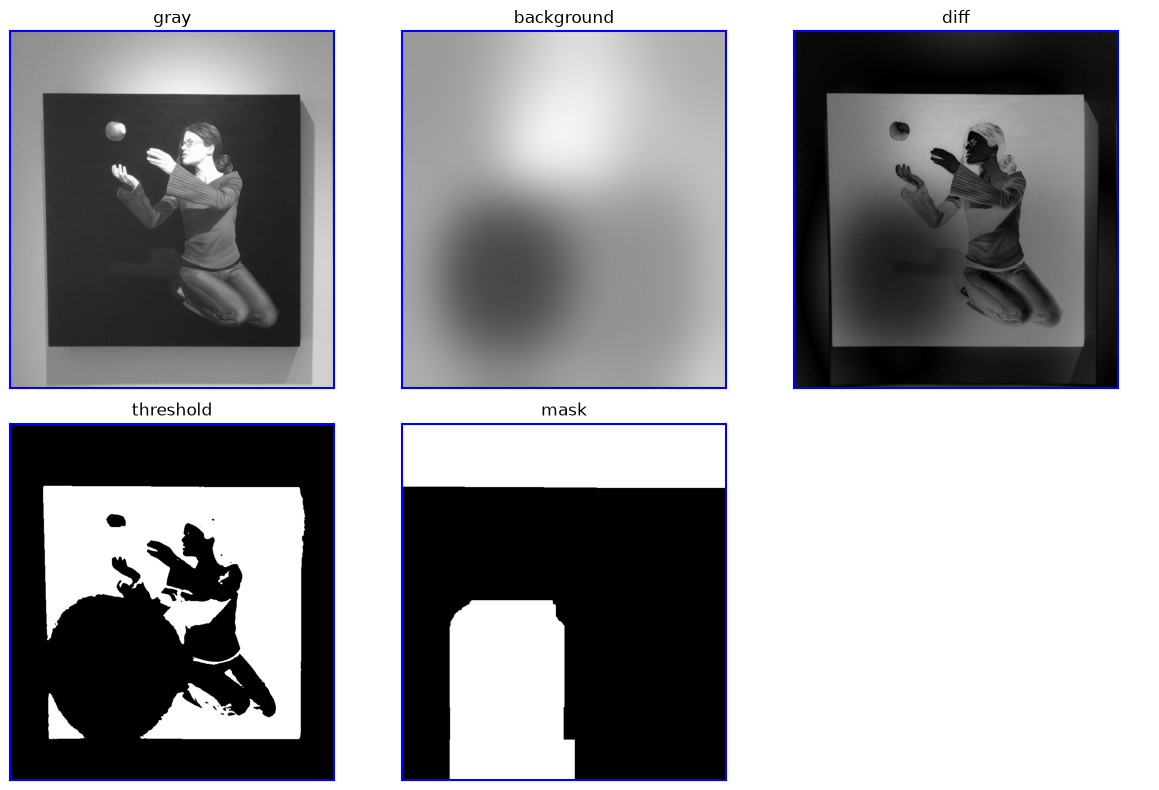

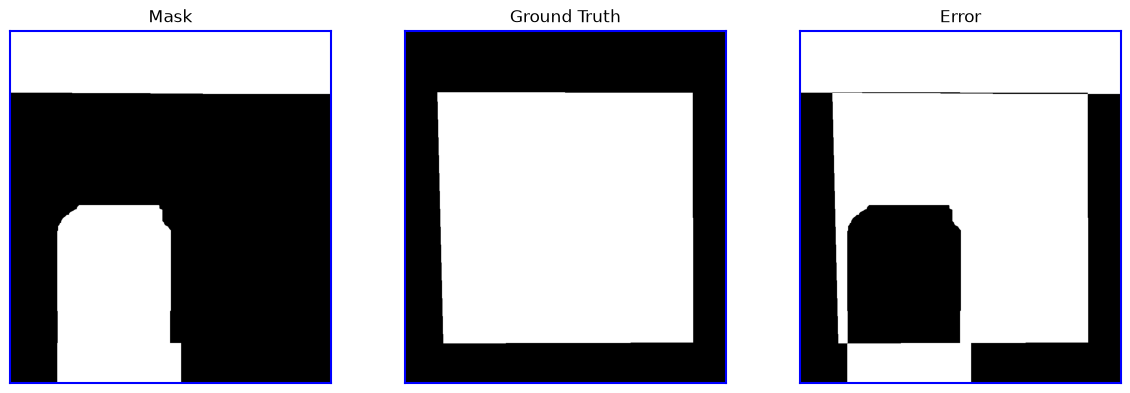

In [11]:
IMG = '00001'
img = cv2.cvtColor(cv2.imread(str(QSD2 / f'{IMG}.jpg')), cv2.COLOR_BGR2RGB)
gt = cv2.imread(str(QSD2 / f'{IMG}.png'), cv2.IMREAD_GRAYSCALE)

mask, steps = background_mask(img, close1_div=8, close2_div=4, return_steps=True)

show(*steps.values(), titles=list(steps.keys()))
show(mask, gt, cv2.absdiff(mask, gt), titles=['Mask', 'Ground Truth', 'Error'])

00016: error = 65.69%, F1 = 0.301
00006: error = 77.41%, F1 = 0.000
00026: error = 96.01%, F1 = 0.054
00029: error = 88.45%, F1 = 0.174
00025: error = 89.62%, F1 = 0.007
00020: error = 71.06%, F1 = 0.331
00010: error = 99.27%, F1 = 0.007
00000: error = 73.08%, F1 = 0.346
00009: error = 93.63%, F1 = 0.012
00015: error = 68.51%, F1 = 0.000

Mitjana: error = 82.27%, F1 = 0.123


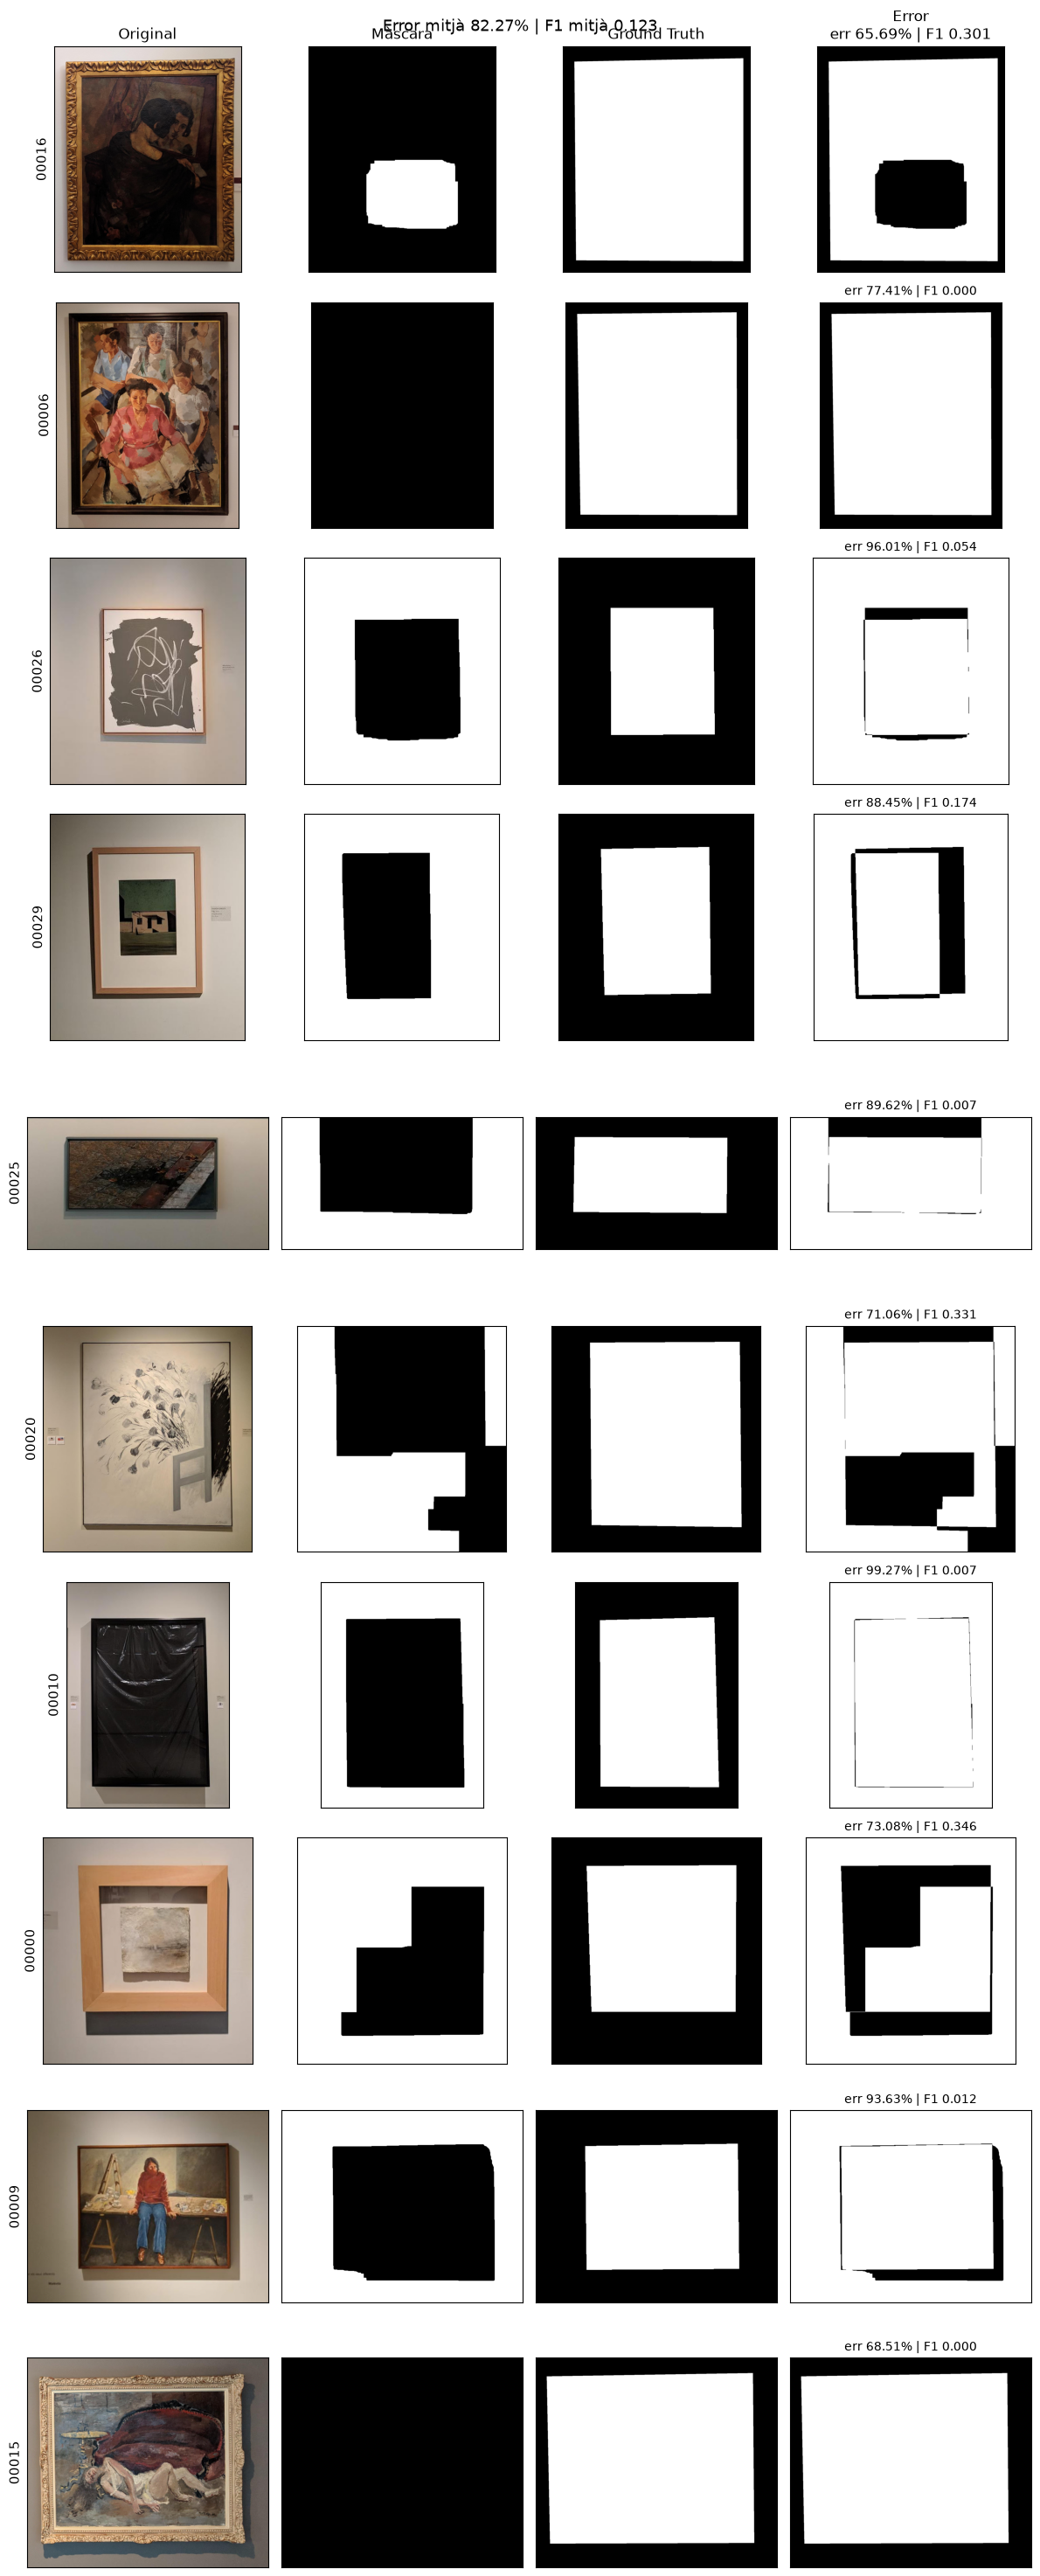

In [12]:
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path().resolve().parent / 'data'
QSD2 = DATA_DIR / 'qsd2_w2'

N_IMAGES = 10
SEED = None  # posa un enter per tenir sempre les mateixes imatges

# Paràmetres del pipeline (denominadors dels kernels)
PARAMS = dict(
    bg_close_div=2.5,
    blur_div=2,
    median_k=5,
    close1_div=10,
    close2_div=5,
    open_div=10,
)


def load_pair(name):
    img = cv2.cvtColor(cv2.imread(str(QSD2 / f'{name}.jpg')), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(str(QSD2 / f'{name}.png'), cv2.IMREAD_GRAYSCALE)
    return img, gt


def metrics(mask, gt):
    pred = mask > 127
    true = gt > 127
    tp = np.sum(pred & true)
    fp = np.sum(pred & ~true)
    fn = np.sum(~pred & true)
    error = np.mean(pred != true)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return error, f1


names = sorted(p.stem for p in QSD2.glob('*.jpg') if (QSD2 / f'{p.stem}.png').exists())
if not names:
    raise FileNotFoundError(f'No hi ha parelles jpg/png a {QSD2}')

rng = random.Random(SEED)
selected = rng.sample(names, min(N_IMAGES, len(names)))

fig, axes = plt.subplots(len(selected), 4, figsize=(12, 3 * len(selected)), squeeze=False)
col_titles = ['Original', 'Màscara', 'Ground Truth', 'Error']

errors, f1s = [], []
for row, name in zip(axes, selected):
    img, gt = load_pair(name)
    mask = background_mask(img, **PARAMS)
    err_map = cv2.absdiff(mask, gt)
    error, f1 = metrics(mask, gt)
    errors.append(error)
    f1s.append(f1)

    for ax, im in zip(row, [img, mask, gt, err_map]):
        if im.ndim == 2:
            ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(im)
        ax.set_xticks([])
        ax.set_yticks([])

    row[0].set_ylabel(name, fontsize=11)
    row[3].set_title(f'err {error:.2%} | F1 {f1:.3f}', fontsize=10)
    print(f'{name}: error = {error:.2%}, F1 = {f1:.3f}')

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title if title != 'Error' else f'{title}\n{ax.get_title()}')

print(f'\nMitjana: error = {np.mean(errors):.2%}, F1 = {np.mean(f1s):.3f}')
fig.suptitle(f'Error mitjà {np.mean(errors):.2%} | F1 mitjà {np.mean(f1s):.3f}', fontsize=13)
plt.tight_layout()
plt.show()